In [1]:
import pandas as pd
import numpy as np
import pickle
import scipy.io

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from tqdm import tqdm
from typing import List

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import adfuller

# FIRST DATASET: JAPAN STUDY

In [2]:
# Load data and create pandas series of only HR

subject_1 = pd.read_csv("./sensors-22-00034-s001/S1_File.csv", index_col = 0)
subject_2 = pd.read_csv("./sensors-22-00034-s001/S2_File.csv", index_col = 0)
subject_3 = pd.read_csv("./sensors-22-00034-s001/S3_File.csv", index_col = 0)

hr_1 = subject_1.loc[:,"True Values"].reset_index(drop=True)
hr_2 = subject_2.loc[:,"True Values"].reset_index(drop=True)
hr_3 = subject_3.loc[:,"True Values"].reset_index(drop=True)

subjects = [subject_1, subject_2, subject_3]

hrs_forecastsar3 = [subjects[i].loc[:,"AR(3) Forecasts"] for i in range(3)]
hrs = [hr_1, hr_2, hr_3]

In [3]:
fig = make_subplots(rows = 3, cols = 1)

fig.add_trace(
    go.Scatter(y=hrs[0]),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(y=hrs[1]), row=2, col=1
)

fig.add_trace(
    go.Scatter(y=hrs[2]), row=3, col=1
)

fig.show()

In [4]:
# We see that there are 2 days and they are approximately correctly cut at the middle (around 1450)
# We will use one for training and one for testing

In [5]:
def model_training_arima(
        data:List,
        order:int,
        intercept: bool,
        integrated:int,
        train_percent: int,
):
    train_sets = []
    test_sets = []
    models = []
    results = []

    m = len(data)

    for i in range(m):

        n = len(data[i])

        idx_train = n*train_percent//100

        train = data[i].iloc[:idx_train] # does not include idx_train
        test = data[i].iloc[idx_train:] # includes it
        
        trend = 'c' if intercept else 'n'
        model = SARIMAX(train, order = (order,integrated,0), trend=trend)
        result = model.fit()

        train_sets.append(train)
        test_sets.append(test)
        models.append(model)
        results.append(result)

    return train_sets, test_sets, models, results
    

In [6]:
# Train AR(3) WITHOUT INTERCEPT, adding one does not particularly give better result, it adds an intercept of around 6 for the first
# time series for instance and makes them process less unit root (sum of coeffs sum to 0.9 ish instead of 1 ish)

trains_ar3, tests_ar3, models_ar3, results_ar3 = model_training_arima(hrs, 1, False, 0, 50)

In [7]:
# We see that we have near unit root 
print(results_ar3[0].summary())

                               SARIMAX Results                                
Dep. Variable:            True Values   No. Observations:                 1432
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -4161.503
Date:                Wed, 25 Mar 2026   AIC                           8327.005
Time:                        18:04:08   BIC                           8337.539
Sample:                             0   HQIC                          8330.939
                               - 1432                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9980      0.001    699.278      0.000       0.995       1.001
sigma2        19.4999      0.373     52.286      0.000      18.769      20.231
Ljung-Box (L1) (Q):                  35.83   Jarque-

In [8]:
# Freeze training parameters and predict 1 step ahead based on true previous values

def forecast_arima(
    results,
    test_sets
):
    m = len(test_sets)
    preds = [pd.Series(index=test_sets[i].index, dtype=float) for i in range(m)]

    for i in range(m):
        current_res = results[i]

        for j in tqdm(range(len(test_sets[i]))):

            yhat = current_res.forecast(steps=1).iloc[0]
            preds[i].iloc[j] = yhat

            current_res = current_res.extend(test_sets[i].iloc[j:j+1])
            
    return preds

In [9]:
predictions_ar3 = forecast_arima(results_ar3, tests_ar3)

100%|██████████| 1433/1433 [00:05<00:00, 285.68it/s]


In [10]:
# Plot our prediction vs true values

fig = make_subplots(rows = 3, cols = 1)

for i in range(3):
    n = len(hrs[i])
    fig.add_trace(
    go.Scatter(x=predictions_ar3[i].index, y=hrs[i].iloc[n//2:].values, mode="lines"),
    row=i+1, col=1
    )
    fig.add_trace(
    go.Scatter(x=predictions_ar3[i].index, y=predictions_ar3[i].values, mode="lines"),
    row=i+1, col=1
    )


fig.show()

In [11]:
# CHECK IF THIS IS CONSISTENT OR IF THE FIRST OBSERVATION IS MISSING SO THERE IS A PROBLEM, OR WE DONT CARE
# compute errors and add to results dataframe

def compute_errors(series, forecast):

    m = len(series)

    maes = []
    rmses = []

    for i in range(m):
        mae = (series[i]-forecast[i]).abs().mean()
        rmse = ((series[i]-forecast[i])**2).mean()**0.5

        maes.append(mae)
        rmses.append(rmse)
    
    return maes, rmses

In [12]:
# This seems to be the results they show in their paper (slightly worse though than what they claim)

full_maes_their, full_rmses_their = compute_errors(series = hrs, forecast = hrs_forecastsar3)

print(np.array(full_maes_their))
print(np.array(full_rmses_their))

[3.06403909 2.64825131 2.54733578]
[4.62235163 4.05522059 3.7124602 ]


In [13]:
# Their AR3 forecasts for the second day (on the same segment that I used for testing)

n = len(hrs[0]) # All 3 subjects are same length here

hrs_forecastsar3_partial = [subjects[i].loc[n//2:,"AR(3) Forecasts"] for i in range(3)]
hrs_partial = [hrs[i].iloc[n//2:] for i in range(3)]

maes_their_partial_ar3, rmses_their_partial_ar3 = compute_errors(series = hrs_partial, forecast = hrs_forecastsar3_partial)

# Our maes and rmses

maes_our_partial_ar3, rmses_our_partial_ar3 = compute_errors(series = tests_ar3, forecast = predictions_ar3)


In [14]:
# We see that we have slightly worse results than in the paper

for i in range(3):
    print(f"---Subject {i}--")
    print("Our MAE: ", maes_our_partial_ar3[i], "Their MAE: ", maes_their_partial_ar3[i])
    print("Our RMSE: ", rmses_our_partial_ar3[i], "Their RMSE: ", rmses_their_partial_ar3[i], "\n")

---Subject 0--
Our MAE:  3.2238858176412797 Their MAE:  3.183156315422191
Our RMSE:  4.9999269769592285 Their RMSE:  4.90175440095253 

---Subject 1--
Our MAE:  2.799145858281864 Their MAE:  2.8029525471039776
Our RMSE:  4.286138228294059 Their RMSE:  4.181499191162704 

---Subject 2--
Our MAE:  2.8374090427657395 Their MAE:  2.805166782972784
Our RMSE:  4.1886200790907955 Their RMSE:  4.092618073439709 



In [15]:
def errors_naive(data, train_percentage):
    naive_maes = []
    naive_rmses = []

    m = len(data)

    for i in range(m):
        idx_train = len(data[i])*train_percentage//100 if train_percentage > 0 else 1   #this is because we would start at index -1 at the next line otherwise
        test_difference = (data[i].iloc[1:]-data[i].shift(1)[1:]).iloc[idx_train-1:]

        mae = test_difference.abs().mean()
        rmse = (test_difference**2).mean()**0.5

        naive_maes.append(mae)
        naive_rmses.append(rmse)
        
    return naive_maes, naive_rmses

In [16]:
# Their AR(3) is still slightly better than naive prediction in average (not on subject 2 however)

# On the whole dataset

naive_maes_full, naive_rmses_full = errors_naive(hrs, 0)

print("-------WHOLE DATASET-------\n")

print("Naive maes:", np.array(naive_maes_full), "\n")
print("Naive rmses:", np.array(naive_rmses_full), "\n")

difference_maes_full = np.array(naive_maes_full) - np.array(full_maes_their)
difference_rmses_full = np.array(naive_rmses_full) - np.array(full_rmses_their)

print("Mean MAE difference:", difference_maes_full.mean())
print("Mean RMSE difference:", difference_rmses_full.mean())

# On our test set


naive_maes_partial, naive_rmses_partial = errors_naive(hrs, 50)


print("\n-------OUR TEST SET-------\n")

print("Naive maes:", np.array(naive_maes_partial), "\n")
print("Naive rmses:", np.array(naive_rmses_partial), "\n")

difference_maes_partial = np.array(naive_maes_partial) - np.array(maes_their_partial_ar3)
difference_rmses_partial = np.array(naive_rmses_partial) - np.array(rmses_their_partial_ar3)

print("Mean MAE difference:", difference_maes_partial.mean())
print("Mean RMSE difference:", difference_rmses_partial.mean())

-------WHOLE DATASET-------

Naive maes: [3.08694134 2.62465084 2.56599162] 

Naive rmses: [4.71975942 4.15683186 3.81785292] 

Mean MAE difference: 0.00598587362407003
Mean RMSE difference: 0.10147059485738301

-------OUR TEST SET-------

Naive maes: [3.20446615 2.78506629 2.82763433] 

Naive rmses: [5.00274407 4.28797664 4.18962042] 

Mean MAE difference: 0.008630379157943846
Mean RMSE difference: 0.10148982383940612


In [17]:
# collect all results in a pandas DataFrame

df_japan = pd.DataFrame(
    {
        "AR(3) maes_full_their": full_maes_their,
        "AR(3) rmses_full_their": full_rmses_their,
        "AR(3) maes_partial_our": maes_our_partial_ar3,
        "AR(3) rmses_partial_our": rmses_our_partial_ar3,
        "AR(3) maes_partial_their": maes_their_partial_ar3,
        "AR(3) rmses_partial_their": rmses_their_partial_ar3,
        "Naive maes_full": naive_maes_full,
        "Naive rmses_full": naive_rmses_full,
        "Naive maes_partial": naive_maes_partial,
        "Naive rmses_partial": naive_rmses_partial,
    },
    index = ["subject1", "subject2", "subject3"]
)

df_japan

,AR(3) maes_full_their,AR(3) rmses_full_their,AR(3) maes_partial_our,AR(3) rmses_partial_our,AR(3) maes_partial_their,AR(3) rmses_partial_their,Naive maes_full,Naive rmses_full,Naive maes_partial,Naive rmses_partial
subject1,3.064039,4.622352,3.223886,4.999927,3.183156,4.901754,3.086941,4.719759,3.204466,5.002744
subject2,2.648251,4.055221,2.799146,4.286138,2.802953,4.181499,2.624651,4.156832,2.785066,4.287977
subject3,2.547336,3.712460,2.837409,4.188620,2.805167,4.092618,2.565992,3.817853,2.827634,4.189620


In [18]:
# Now we will first do ARIMA instead of AR which hopefully will give better results already

trains_arima3, tests_arima3, models_arima3, results_arima3 = model_training_arima(hrs, 1, False, 1, 50)

In [19]:
print(results_arima3[0].summary())

                               SARIMAX Results                                
Dep. Variable:            True Values   No. Observations:                 1432
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -4138.694
Date:                Wed, 25 Mar 2026   AIC                           8281.388
Time:                        18:04:24   BIC                           8291.920
Sample:                             0   HQIC                          8285.321
                               - 1432                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1573      0.017      9.267      0.000       0.124       0.191
sigma2        19.0378      0.392     48.524      0.000      18.269      19.807
Ljung-Box (L1) (Q):                   0.15   Jarque-

In [20]:
# Freeze training parameters and predict 1 step ahead based on true previous values, forecast ARIMA(1,1,0)

predictions_arima3 = forecast_arima(results_arima3, tests_arima3)


100%|██████████| 1433/1433 [00:05<00:00, 258.97it/s]


In [21]:
#ARIMA(1,1,0) errors

maes_our_partial_arima, rmses_our_partial_arima = compute_errors(series = tests_arima3, forecast = predictions_arima3)

In [22]:
print(np.array(maes_our_partial_arima))
print(np.array(rmses_our_partial_arima))

[3.21560826 2.84213895 2.82998385]
[4.96495986 4.33484608 4.17497303]


In [23]:
# ARIMA(3,1,0) does slightly better than AR(3) but still does not outperform their AR(3)

df_japan["ARIMA(3,1,0) maes_partial"] = maes_our_partial_arima
df_japan["ARIMA(3,1,0) rmses_partial"] = rmses_our_partial_arima

df_japan

,AR(3) maes_full_their,AR(3) rmses_full_their,AR(3) maes_partial_our,AR(3) rmses_partial_our,AR(3) maes_partial_their,AR(3) rmses_partial_their,Naive maes_full,Naive rmses_full,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial"
subject1,3.064039,4.622352,3.223886,4.999927,3.183156,4.901754,3.086941,4.719759,3.204466,5.002744,3.215608,4.964960
subject2,2.648251,4.055221,2.799146,4.286138,2.802953,4.181499,2.624651,4.156832,2.785066,4.287977,2.842139,4.334846
subject3,2.547336,3.712460,2.837409,4.188620,2.805167,4.092618,2.565992,3.817853,2.827634,4.189620,2.829984,4.174973


In [24]:
# Train and predict with xgboost

def predict_xgboost(
    data: List,
    train_percent: int
):
    test_sets = []
    predictions = []

    m = len(data)

    for i in range(m):

        n = len(data[i])

        df = pd.DataFrame({
            "y": data[i],
            "lag1": data[i].shift(1),
            "lag2": data[i].shift(2),
            "lag3": data[i].shift(3),
        })

        #df["rolling_mean_3"] = df["lag1"].rolling(3).mean()
        df["rolling_std_3"] = df["lag1"].rolling(3).std()

        df["diff1"] = df["lag1"].diff(1)
        df["diff2"] = df["lag1"].diff(2)

        df["ema_5"] = df["y"].shift(1).ewm(span=5).mean()

        idx_train = n*train_percent//100

        df = df.dropna() # remove rows with NaN due to shifting

        X_train = df.loc[:idx_train-1,].drop("y",axis=1) # does not include idx_train
        X_test = df.loc[idx_train:,].drop("y",axis=1) # includes it

        y_train = df.loc[:idx_train-1,"y"]
        y_test = df.loc[idx_train:,"y"]

        model = XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            eval_metric="rmse"
        )
        
        model.fit(X_train, y_train)

        test_sets.append(y_test)

        preds = model.predict(X_test)
        predictions.append(preds)

    maes, rmses = compute_errors(test_sets, predictions)

    return maes, rmses


In [25]:
maes_xgboost, rmses_xgboost = predict_xgboost(hrs, 50)

In [26]:
df_japan["XGBoost maes_partial"] = maes_xgboost
df_japan["XGBoost rmses_partial"] = rmses_xgboost

df_japan

,AR(3) maes_full_their,AR(3) rmses_full_their,AR(3) maes_partial_our,AR(3) rmses_partial_our,AR(3) maes_partial_their,AR(3) rmses_partial_their,Naive maes_full,Naive rmses_full,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial
subject1,3.064039,4.622352,3.223886,4.999927,3.183156,4.901754,3.086941,4.719759,3.204466,5.002744,3.215608,4.964960,3.999381,7.484896
subject2,2.648251,4.055221,2.799146,4.286138,2.802953,4.181499,2.624651,4.156832,2.785066,4.287977,2.842139,4.334846,3.123448,4.446865
subject3,2.547336,3.712460,2.837409,4.188620,2.805167,4.092618,2.565992,3.817853,2.827634,4.189620,2.829984,4.174973,2.959469,4.235963


In [27]:
# Even with some feature engineering and hyperparameter tuning, XGBoost is underperforming

In [28]:
# We are now going to implement a markov switching model and hope it beats their AR(3)
# Train Test 50-50 split and model training (1 day and 1 day) MS_AR(3) on differenced series

def model_training_msar(
        data:str,
        order:int,
        switching_var:bool,
        train_percent: int
):
    
    train_sets = []
    test_sets = []

    models_msar= []
    results_msar = []

    # We differenciate ourself as the model doesn't handle it

    m = len(data)
    differenced_hrs = [(data[i]-data[i].shift(1)).iloc[1:].reset_index(drop=True) for i in range(m)]

    for i in range(m):

        n = len(differenced_hrs[i])

        idx_train = n*train_percent//100

        train = differenced_hrs[i].iloc[:idx_train] #does not include idx_train
        test = differenced_hrs[i].iloc[idx_train:] #includes it

        model = MarkovAutoregression(
        train,
        k_regimes=2,
        order=order,
        trend="n",
        switching_ar=True,        # AR coefficients can differ by regime
        switching_variance=switching_var   # regime-specific variance or not
        )

        #em_iter=0,           # <-- skip EM
        #method="bfgs",       # or "nm" (Nelder–Mead) if BFGS has trouble
        #maxiter=100,

        result = model.fit(
            #em_iter = 
        )

        train_sets.append(train)
        test_sets.append(test)
        models_msar.append(model)
        results_msar.append(result)
    
    return train_sets, test_sets, models_msar, results_msar

In [29]:
trains_msar3var, tests_msar3var, models_msar3var, results_msar3var = model_training_msar(
        data = hrs,
        order = 1,
        switching_var = True,
        train_percent = 50
)

In [30]:
# We are going to construct the one step forecasts

In [31]:
# Store parameters of each model that will be used for 1 step forecasting 

def model_parameters(results:List):

    m = len(results)

    order = max(
        int(idx.split("L")[1].split("[")[0])
        for idx in results[0].params.index
        if idx.startswith("ar.L")
    )

    if "sigma2" in results[0].params.index:
        switching_var = False
    elif any(idx.startswith("sigma2[") for idx in results[0].params.index):
        switching_var = True


    Ps = [] # transition matrices for each model

    ARs_regime0 = [] # Ar parameters of regime 0 for each model
    ARs_regime1 = [] # Ar parameters of regime 1 for each model

    if switching_var:
        Vars_regime0 = [] # Var of regime 0 for each model
        Vars_regime1 = [] # Var of regime 1 for each model
    else:
        Vars = [] # General Var for each model in non switching var case

    for i in range(m):
        P = np.array(
            [
                [results[i].params.loc["p[0->0]"], 1 - results[i].params.loc["p[0->0]"]],
                [results[i].params.loc["p[1->0]"], 1 - results[i].params.loc["p[1->0]"]]
            ]
        )
        Ps.append(P)
        AR_regime0 = np.array(
            [
                results[i].params.loc[f"ar.L{k}[0]"]
                for k in range(1, order + 1)
            ]
        )
        ARs_regime0.append(AR_regime0)

        AR_regime1 = np.array(
            [
                results[i].params.loc[f"ar.L{k}[1]"]
                for k in range(1, order + 1)
            ]
        )
        ARs_regime1.append(AR_regime1)

        if switching_var:
            Var_regime0 = results[i].params.loc["sigma2[0]"]
            Var_regime1 = results[i].params.loc["sigma2[1]"] 

            Vars_regime0.append(Var_regime0)
            Vars_regime1.append(Var_regime1)
        else:
            Var = results[i].params.loc["sigma2"]
            Vars.append(Var)

    parameters = (
        [Ps]
        + [ARs_regime0]
        + [ARs_regime1]
        + ([Vars] if not switching_var else [Vars_regime0, Vars_regime1])
    )

    return parameters


In [32]:
parameters_msar3var = model_parameters(results_msar3var)

In [33]:
# 1 step forecasts for differenced time series

def forecast_msar(parameters: List, results: List, train_sets, test_sets):

    m = len(results)

    order = max(
        int(idx.split("L")[1].split("[")[0])
        for idx in results[0].params.index
        if idx.startswith("ar.L")
    )

    if "sigma2" in results[0].params.index:
        switching_var = False
    elif any(idx.startswith("sigma2[") for idx in results[0].params.index):
        switching_var = True
    
    Ps = parameters[0]
    ARs_regime0 = parameters[1]
    ARs_regime1 = parameters[2]

    if switching_var:
        Vars_regime0 = parameters[3]
        Vars_regime1 = parameters[4]
    else:
        Vars = parameters[3]


    differenced_forecasts = [[] for _ in range(m)]
    probas_state0_forecast = [[] for _ in range(m)]
    probas_state0_filtered = [[] for _ in range(m)]

    for i in range(m):

        # This is xi_T|T for the last observation of the train set
        # We could have equivalently used filtered_marginal_probabilities as it is the last t (so t=T) xi_t|t = xi_t|T
        xi_t = results[i].smoothed_marginal_probabilities.iloc[-1].to_numpy() 

        for j in range(len(test_sets[i])):

            # for the first predictions, we need to take values from the end of the train sets to construct lagged vector
            if j < order:
                y_lagged = pd.concat((test_sets[i].iloc[:j].iloc[::-1], train_sets[i].iloc[-order+j:].iloc[::-1]))
            else:
                y_lagged = test_sets[i].iloc[j-order:j].iloc[::-1] # (y_t-1, y_t-2, y_t-3)

            xi_predicted = Ps[i].T @ xi_t # xi_t+1|t

            expected_ys = np.array(
                [
                    ARs_regime0[i] @ y_lagged,
                    ARs_regime1[i] @ y_lagged,
                ]
            )
            y_hat = xi_predicted @ expected_ys

            y = test_sets[i].iloc[j]

            mu0 = ARs_regime0[i] @ y_lagged
            mu1 = ARs_regime1[i] @ y_lagged

            if switching_var:
                var0 = Vars_regime0[i]
                var1 = Vars_regime1[i]

                eta_t = np.array([
                    np.exp(-(y-mu0)**2/(2*var0)) / (np.sqrt(2*np.pi*var0)),
                    np.exp(-(y-mu1)**2/(2*var1)) / (np.sqrt(2*np.pi*var1))
                ])
            else:
                var = Vars[i]

                eta_t = np.array([
                    np.exp(-(y-mu0)**2/(2*var)) / (np.sqrt(2*np.pi*var)),
                    np.exp(-(y-mu1)**2/(2*var)) / (np.sqrt(2*np.pi*var))
                ])

            xi_t = (xi_predicted * eta_t)/np.sum(xi_predicted * eta_t)

            probas_state0_forecast[i].append(xi_predicted[0])
            probas_state0_filtered[i].append(xi_t[0])

            differenced_forecasts[i].append(y_hat)

    differenced_forecasts = [
        pd.Series(differenced_forecasts[i], index=test_sets[i].index)
        for i in range(m)
    ]

    probas_state0_forecast = [
        pd.Series(probas_state0_forecast[i], index=test_sets[i].index)
        for i in range(m)
    ]

    probas_state0_filtered = [
        pd.Series(probas_state0_filtered[i], index=test_sets[i].index)
        for i in range(m)
    ]

    return differenced_forecasts, probas_state0_forecast, probas_state0_filtered


In [34]:
differenced_forecasts_msar3var, probas_state0_forecast_msar3var, probas_state0_filtered_msar3var = forecast_msar(
    parameters_msar3var,
    results_msar3var,
    trains_msar3var,
    tests_msar3var
)

In [35]:
maes_msar3var, rmses_msar3var = compute_errors(series = tests_msar3var, forecast = differenced_forecasts_msar3var)

In [36]:
df_japan["MSAR(3)var diff maes_partial"] = maes_msar3var
df_japan["MSAR(3)var diff rmses_partial"] = rmses_msar3var

df_japan

,AR(3) maes_full_their,AR(3) rmses_full_their,AR(3) maes_partial_our,AR(3) rmses_partial_our,AR(3) maes_partial_their,AR(3) rmses_partial_their,Naive maes_full,Naive rmses_full,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial
subject1,3.064039,4.622352,3.223886,4.999927,3.183156,4.901754,3.086941,4.719759,3.204466,5.002744,3.215608,4.964960,3.999381,7.484896,3.190845,4.992319
subject2,2.648251,4.055221,2.799146,4.286138,2.802953,4.181499,2.624651,4.156832,2.785066,4.287977,2.842139,4.334846,3.123448,4.446865,2.830212,4.343887
subject3,2.547336,3.712460,2.837409,4.188620,2.805167,4.092618,2.565992,3.817853,2.827634,4.189620,2.829984,4.174973,2.959469,4.235963,2.831127,4.178278


In [37]:
# All same without switching Var
trains_msar3, tests_msar3, models_msar3, results_msar3 = model_training_msar(
        data = hrs,
        order = 3,
        switching_var = False,
        train_percent = 50
)

parameters_msar3 = model_parameters(results_msar3)

differenced_forecasts_msar3, probas_state0_forecast_msar3, probas_state0_filtered_msar3 = forecast_msar(
    parameters_msar3,
    results_msar3,
    trains_msar3,
    tests_msar3
)

maes_msar3, rmses_msar3 = compute_errors(series = tests_msar3, forecast = differenced_forecasts_msar3)

df_japan["MSAR(3) diff maes_partial"] = maes_msar3
df_japan["MSAR(3) diff rmses_partial"] = rmses_msar3

df_japan

,AR(3) maes_full_their,AR(3) rmses_full_their,AR(3) maes_partial_our,AR(3) rmses_partial_our,AR(3) maes_partial_their,AR(3) rmses_partial_their,Naive maes_full,Naive rmses_full,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial,MSAR(3) diff maes_partial,MSAR(3) diff rmses_partial
subject1,3.064039,4.622352,3.223886,4.999927,3.183156,4.901754,3.086941,4.719759,3.204466,5.002744,3.215608,4.964960,3.999381,7.484896,3.190845,4.992319,3.173447,4.929258
subject2,2.648251,4.055221,2.799146,4.286138,2.802953,4.181499,2.624651,4.156832,2.785066,4.287977,2.842139,4.334846,3.123448,4.446865,2.830212,4.343887,2.808976,4.269837
subject3,2.547336,3.712460,2.837409,4.188620,2.805167,4.092618,2.565992,3.817853,2.827634,4.189620,2.829984,4.174973,2.959469,4.235963,2.831127,4.178278,2.856841,4.152698


In [38]:
# If we compare to our AR3, msar is outperforming on all subjects

Without switching variance:

**Subject 1 (outperforms)**
- First regime has minor negative coefficients everywhere (sum ≈ -0.1)
- Second regime is highly persistent (1.23, 0.27, -0.5), coefficients sum to ≈ 1  

| Transition | Probability |
|------------|-------------|
| p[0→0]     | 0.9150      |
| p[1→0]     | 0.8518      |

**Subject 2 (outperforms)**
- First regime has minor negative coefficients everywhere (sum ≈ -0.1)
- Second regime is kind of shrinking values (1.36, -1.45, 0.55), coefficients sum to ≈ 0.5  

| Transition | Probability |
|------------|-------------|
| p[0→0]     | 0.9522      |
| p[1→0]     | 0.7119      |

**Subject 3**
- First regime has minor negative coefficients everywhere (sum ≈ -0.02)
- Second regime has big negative coefficients (-0.86, -0.78, -0.55), coefficients sum to ≈ -2.2  

| Transition | Probability |
|------------|-------------|
| p[0→0]     | 0.7760      |
| p[1→0]     | 0.6507      |

In [39]:
print(results_msar3var[0].summary())

                         Markov Switching Model Results                         
Dep. Variable:              True Values   No. Observations:                 1431
Model:             MarkovAutoregression   Log Likelihood               -3912.152
Date:                  Wed, 25 Mar 2026   AIC                           7836.304
Time:                          18:04:51   BIC                           7867.901
Sample:                               0   HQIC                          7848.103
                                 - 1431                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         7.6656      0.619     12.385      0.000       6.453       8.879
ar.L1         -0.1131      0.032    

In [40]:
print(results_msar3[0].summary())

                         Markov Switching Model Results                         
Dep. Variable:              True Values   No. Observations:                 1429
Model:             MarkovAutoregression   Log Likelihood               -4032.274
Date:                  Wed, 25 Mar 2026   AIC                           8082.547
Time:                          18:04:51   BIC                           8129.930
Sample:                               0   HQIC                          8100.242
                                 - 1429                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0096      0.030     -0.324      0.746      -0.067       0.048
ar.L2         -0.1044      0.028    

In [41]:
"""
models_msar3var
results_msar3var

models_msar3
results_msar3

differenced_hrs

partial_differenced_hrs

differenced_forecasts_msar3var
probas_state0_forecast_msar3var
probas_state0_filtered_msar3var 
#add smoothed

differenced_forecasts_msar3
probas_state0_forecast_msar3
probas_state0_filtered_msar3
"""

'\nmodels_msar3var\nresults_msar3var\n\nmodels_msar3\nresults_msar3\n\ndifferenced_hrs\n\npartial_differenced_hrs\n\ndifferenced_forecasts_msar3var\nprobas_state0_forecast_msar3var\nprobas_state0_filtered_msar3var \n#add smoothed\n\ndifferenced_forecasts_msar3\nprobas_state0_forecast_msar3\nprobas_state0_filtered_msar3\n'

In [42]:
# We see that it approx works, but given that the ascending and descending phases are very short (only 2 to 3 time steps)
# It is not able to put high confidence in the persistent regime as it always quickly switches back to the other one
# That is also observable from the difference between forecasted probas and filtered probas, forecasted are always
# super high for regime 0 whereas filtered ones can better "see" that it indeed switch regimes
# from 1810 to 1815 we can that there is a jump from 1811 to 1812 in the original time series (high value at 1811 for differenced ts)
# the model could not forecast that directly (still high proba for 1811), but the filtered one captured it of course (small proba for filtered 1811)
# then the model was a bit less confident about the actual regime for the next time step and would have been less and less confident probably 
# if the gap kept staying the same or even bigger, the problem is that the time series immediately stabilized and didnt continue the ascent
# that's it why for step 1812 the forecast proba is 0.85 and the filtered one where we observed that the movement didn't continue is 0.99

# Also not a lot of data available as the time series are rather short

fig = make_subplots(rows = 4, cols = 1)


fig.add_trace(
go.Scatter(x=hrs[0].iloc[n//2:].index, y=hrs[0].iloc[n//2:].values, mode="lines"),
row=1, col=1
)
fig.add_trace(
go.Scatter(x=tests_msar3[0].index, y=tests_msar3[0].values, mode="lines"),
row=2, col=1
)
fig.add_trace(
go.Scatter(x=probas_state0_forecast_msar3[0].index, y=probas_state0_forecast_msar3[0].values, mode="lines"),
row=3, col=1
)
fig.add_trace(
go.Scatter(x=probas_state0_forecast_msar3[0].index, y=probas_state0_filtered_msar3[0].values, mode="lines"),
row=4, col=1
)


fig.show()

Saved msar_regimes_subject1.pdf and .png


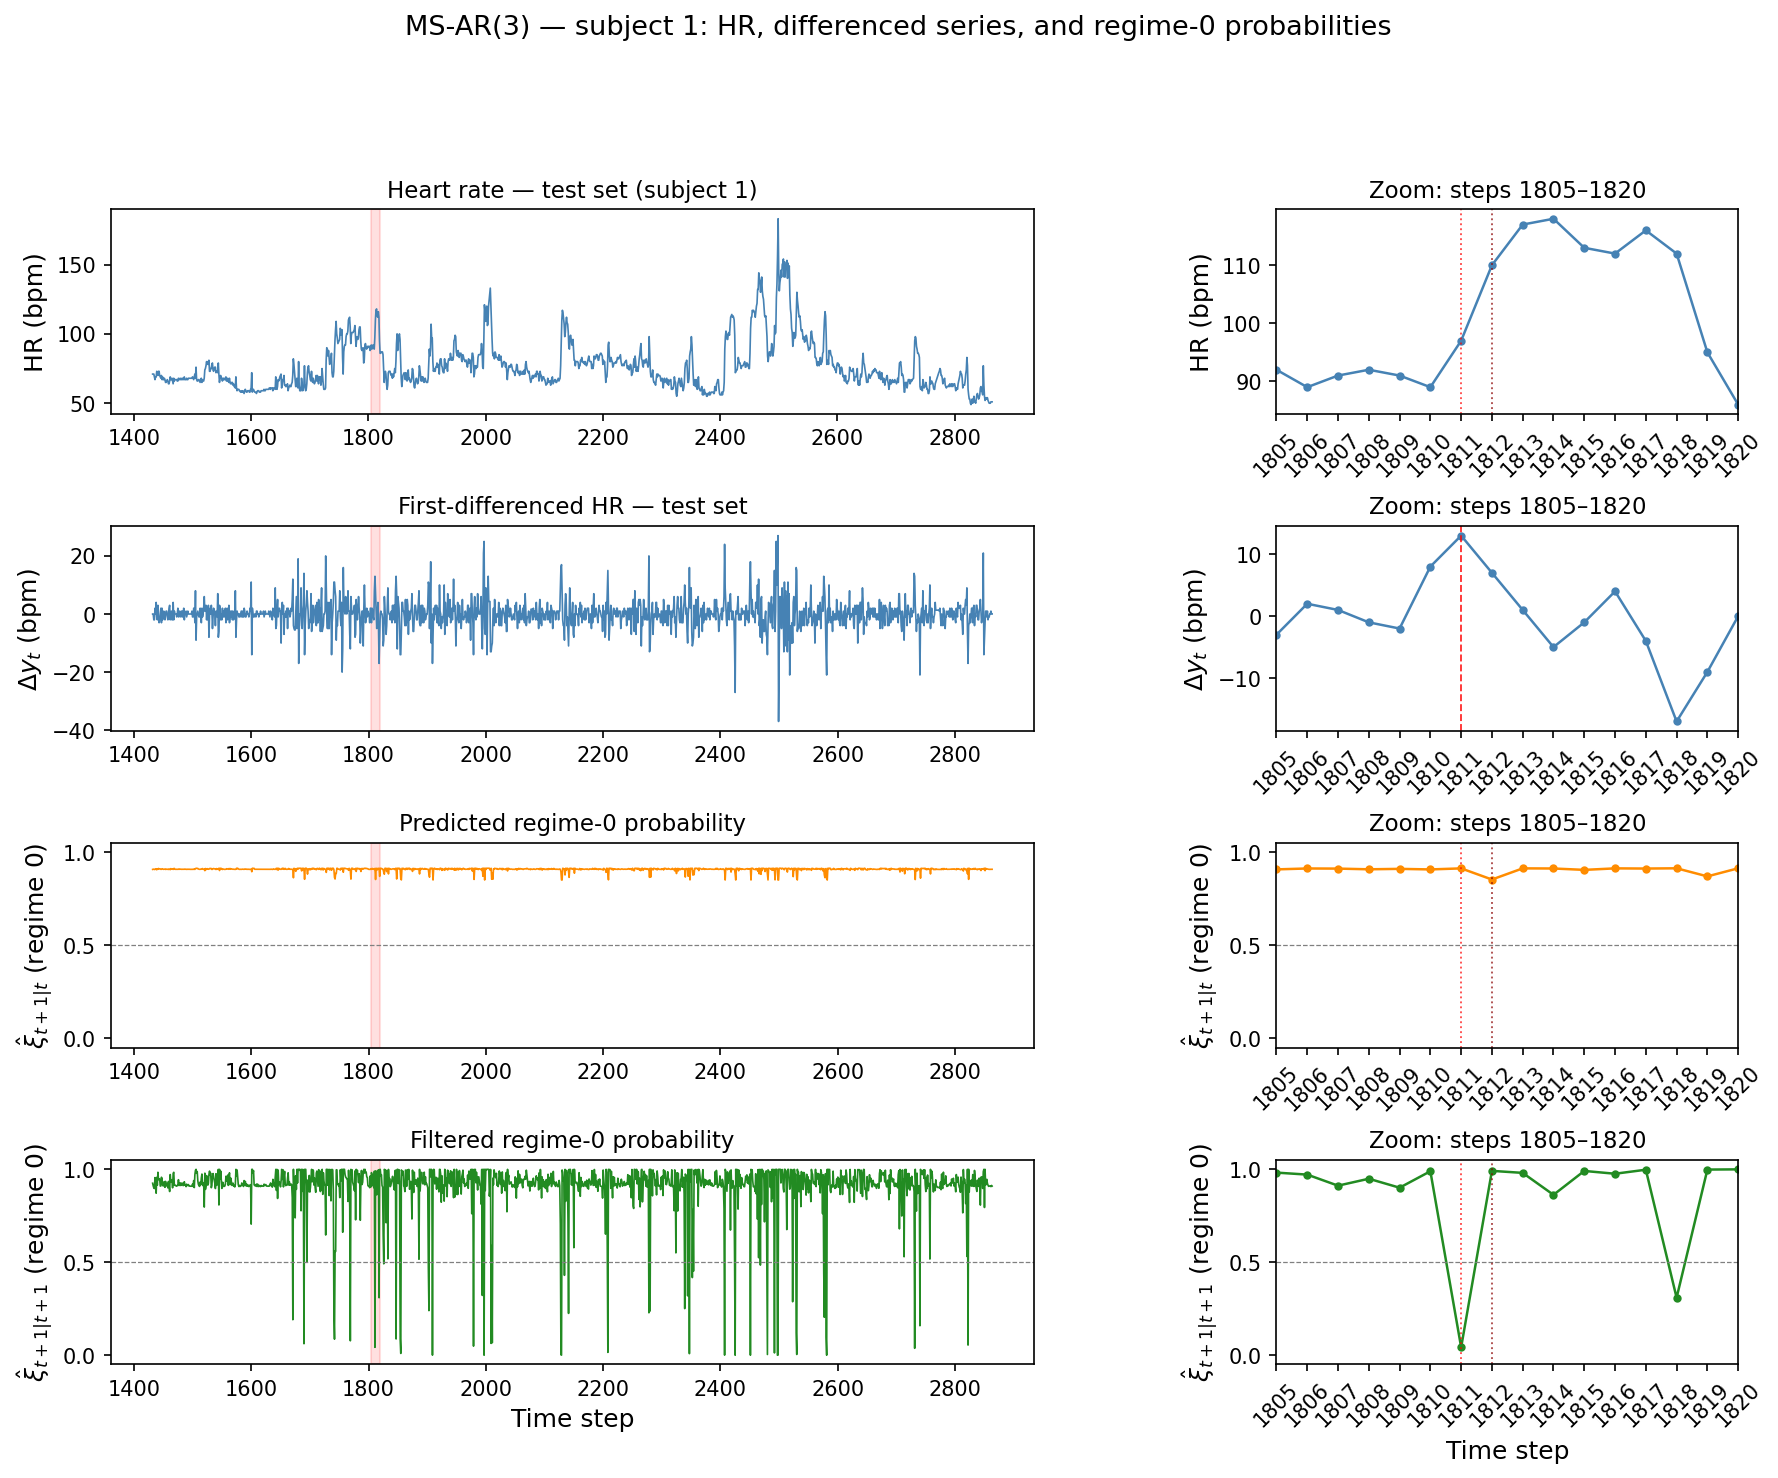

In [43]:
# Claude generated "translation" of the cell above so that everything appears cleanly

import matplotlib
matplotlib.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
})
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── parameters ────────────────────────────────────────────────────
subject_id = 0
ZOOM_START = 1805
ZOOM_END   = 1820

# ── data slices ───────────────────────────────────────────────────
n = len(hrs[subject_id])
end_obs_idx = n * 50 // 100

hr_test        = hrs[subject_id].iloc[end_obs_idx:]
diff_test      = tests_msar3[subject_id]       # already differenced test set
proba_forecast = probas_state0_forecast_msar3[subject_id]
proba_filtered = probas_state0_filtered_msar3[subject_id]

# ── figure layout: 4 rows × 2 cols (full | zoom) ──────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(4, 2, width_ratios=[2, 1], hspace=0.55, wspace=0.35)

labels_left = [
    'HR (bpm)',
    r'$\Delta y_t$ (bpm)',
    r'$\hat{\xi}_{t+1|t}$ (regime 0)',
    r'$\hat{\xi}_{t+1|t+1}$ (regime 0)',
]
titles_left = [
    'Heart rate — test set (subject 1)',
    'First-differenced HR — test set',
    'Predicted regime-0 probability',
    'Filtered regime-0 probability',
]

series = [
    (hr_test.index,        hr_test.values),
    (diff_test.index,      diff_test.values),
    (proba_forecast.index, proba_forecast.values),
    (proba_filtered.index, proba_filtered.values),
]

colors = ['steelblue', 'steelblue', 'darkorange', 'forestgreen']

axes_left  = []
axes_right = []

for row in range(4):
    ax_l = fig.add_subplot(gs[row, 0])
    ax_r = fig.add_subplot(gs[row, 1])
    axes_left.append(ax_l)
    axes_right.append(ax_r)

    x, y = series[row]

    # full series
    ax_l.plot(x, y, color=colors[row], linewidth=0.8)
    ax_l.set_ylabel(labels_left[row])
    ax_l.set_title(titles_left[row], fontsize=11)
    ax_l.axvspan(ZOOM_START, ZOOM_END, alpha=0.12, color='red')

    # zoom
    mask = (x >= ZOOM_START) & (x <= ZOOM_END)
    ax_r.plot(x[mask], y[mask], color=colors[row], linewidth=1.2, marker='o',
              markersize=3)
    ax_r.set_xlim(ZOOM_START, ZOOM_END)
    ax_r.set_ylabel(labels_left[row])
    ax_r.set_title(f'Zoom: steps {ZOOM_START}–{ZOOM_END}', fontsize=11)

    # shade proba panels at [0,1]
    if row >= 2:
        ax_l.set_ylim(-0.05, 1.05)
        ax_r.set_ylim(-0.05, 1.05)
        ax_l.axhline(0.5, color='grey', linewidth=0.6, linestyle='--')
        ax_r.axhline(0.5, color='grey', linewidth=0.6, linestyle='--')

    # x-label only on bottom row
    if row == 3:
        ax_l.set_xlabel('Time step')
        ax_r.set_xlabel('Time step')

# annotate key events on zoom panels
import numpy as np
for row, ax_r in enumerate(axes_right):
    if row == 1:
        # differenced series: single dashed line at 1811 where the jump value appears
        ax_r.axvline(1811, color='red', linewidth=0.9, linestyle='--', alpha=0.8)
    else:
        # HR and probability panels: lines at both 1811 and 1812
        ax_r.axvline(1811, color='red', linewidth=0.9, linestyle=':', alpha=0.7)
        ax_r.axvline(1812, color='darkred', linewidth=0.9, linestyle=':', alpha=0.7)

# integer x-axis ticks on all zoom panels
for ax_r in axes_right:
    ax_r.set_xticks(np.arange(ZOOM_START, ZOOM_END + 1, 1))
    ax_r.tick_params(axis='x', rotation=45)

fig.suptitle(
    'MS-AR(3) — subject 1: HR, differenced series, and regime-0 probabilities',
    fontsize=13, y=1.01
)

plt.savefig('msar_regimes_subject1.pdf', bbox_inches='tight')
plt.savefig('msar_regimes_subject1.png', bbox_inches='tight', dpi=150)
print("Saved msar_regimes_subject1.pdf and .png")
plt.show()

# SECOND DATASET DALIA

In [44]:
# We are going to reuse most of the things we did in the previous section and apply them to this dataset.

In [45]:
datasets=[]
for i in range(1, 16):
    with open(f"./PPG_FieldStudy/S{i}/S{i}.pkl", "rb") as f:
        data = pickle.load(f, encoding="latin1")
    datasets.append(data)
print(datasets[0].keys())
print(datasets[0]['label'])

hrs=[]
for i in range(15):
    hrs.append(pd.Series(datasets[i]['label']).reset_index(drop=True))

dict_keys(['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject'])
[49.61136908 50.32399248 52.70833578 ... 84.004991   85.79625673
 87.4113988 ]


In [46]:
m = len(hrs)

fig = make_subplots(rows = m, cols = 1, shared_xaxes=True)

for i in range(m):
    fig.add_trace(
        go.Scatter(y=hrs[i]),
        row=i+1, col=1
    )

fig.show()

In [47]:
trains_ar3, tests_ar3, models_ar3, results_ar3 = model_training_arima(hrs, 3, False, 0, 50)

In [48]:
print(results_ar3[0].summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2301
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -4779.610
Date:                Wed, 25 Mar 2026   AIC                           9567.220
Time:                        18:06:13   BIC                           9590.184
Sample:                             0   HQIC                          9575.592
                               - 2301                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5007      0.012    120.878      0.000       1.476       1.525
ar.L2         -0.6449      0.023    -28.394      0.000      -0.689      -0.600
ar.L3          0.1438      0.014      9.921      0.0

In [49]:
predictions_ar3 = forecast_arima(results_ar3, tests_ar3)

100%|██████████| 1983/1983 [00:07<00:00, 260.39it/s]


In [50]:
maes_our_partial_ar3, rmses_our_partial_ar3 = compute_errors(series = tests_ar3, forecast = predictions_ar3)

In [51]:
# Naive prediction on test set

naive_maes_partial, naive_rmses_partial = errors_naive(hrs, 50)

In [52]:
# We see that ar(3) is better than naive

for i in range(m):
    print(f"---Subject {i}---")
    print("Our MAE: ", maes_our_partial_ar3[i], "Naive MAE: ", naive_maes_partial[i])
    print("Our RMSE: ", rmses_our_partial_ar3[i], "Naive RMSE: ", naive_rmses_partial[i])

---Subject 0---
Our MAE:  1.4985560233039987 Naive MAE:  1.6574192116622717
Our RMSE:  1.9748319029537535 Naive RMSE:  2.1705840888959207
---Subject 1---
Our MAE:  1.1266615230135204 Naive MAE:  1.622174693616109
Our RMSE:  1.5127952767495418 Naive RMSE:  2.1343608951163904
---Subject 2---
Our MAE:  1.2091983064235572 Naive MAE:  1.6757032660180902
Our RMSE:  1.6157781920661736 Naive RMSE:  2.2136948116534847
---Subject 3---
Our MAE:  1.1968373064936095 Naive MAE:  1.5288226607685593
Our RMSE:  1.5934003816789193 Naive RMSE:  2.0206062886668557
---Subject 4---
Our MAE:  0.7540765319175607 Naive MAE:  1.0543043280536617
Our RMSE:  1.0381390666740395 Naive RMSE:  1.4073445082653206
---Subject 5---
Our MAE:  1.1139293023358485 Naive MAE:  1.8045497467004108
Our RMSE:  1.6813200313832044 Naive RMSE:  2.662856241902379
---Subject 6---
Our MAE:  1.8464899126087015 Naive MAE:  1.9525998539133376
Our RMSE:  2.4119795942970867 Naive RMSE:  2.5282804123067986
---Subject 7---
Our MAE:  1.94857658

In [53]:
# collect all results in a pandas DataFrame

index = [f"subject{i}" for i in range(1, 16)]

df = pd.DataFrame(
    {
        "AR(3) maes_partial": maes_our_partial_ar3,
        "AR(3) rmses_partial": rmses_our_partial_ar3,
        "Naive maes_partial": naive_maes_partial,
        "Naive rmses_partial": naive_rmses_partial,
    },
    index=index
)

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial
subject1,1.498556,1.974832,1.657419,2.170584
subject2,1.126662,1.512795,1.622175,2.134361
subject3,1.209198,1.615778,1.675703,2.213695
subject4,1.196837,1.593400,1.528823,2.020606
subject5,0.754077,1.038139,1.054304,1.407345
subject6,1.113929,1.681320,1.804550,2.662856
subject7,1.846490,2.411980,1.952600,2.528280
subject8,1.948577,2.690352,2.009046,2.735137
subject9,0.733643,1.014048,1.087093,1.500116
subject10,0.622319,0.818711,0.697202,0.918422


In [54]:
# Now we will first do ARIMA instead of AR which hopefully will give better results already
# No intercept here (adding one almost doesnt change anything)

trains_arima3, tests_arima3, models_arima3, results_arima3 = model_training_arima(hrs, 3, False, 1, 50)

In [55]:
print(results_arima3[1].summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2049
Model:               SARIMAX(3, 1, 0)   Log Likelihood               -3742.981
Date:                Wed, 25 Mar 2026   AIC                           7493.962
Time:                        18:08:20   BIC                           7516.460
Sample:                             0   HQIC                          7502.213
                               - 2049                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8180      0.017     48.856      0.000       0.785       0.851
ar.L2         -0.4135      0.021    -19.656      0.000      -0.455      -0.372
ar.L3         -0.1492      0.019     -7.905      0.0

In [56]:
# Freeze training parameters and predict 1 step ahead based on true previous values, forecast ARIMA(1,1,0)

predictions_arima3 = forecast_arima(results_arima3, tests_arima3)

100%|██████████| 1983/1983 [00:07<00:00, 260.93it/s]


In [57]:
#ARIMA(1,1,0) errors

maes_our_partial_arima, rmses_our_partial_arima = compute_errors(series = tests_arima3, forecast = predictions_arima3)

In [58]:
# ARIMA(3,1,0) does slightly better than AR(3) but still does not outperform their AR(3)

df["ARIMA(3,1,0) maes_partial"] = maes_our_partial_arima
df["ARIMA(3,1,0) rmses_partial"] = rmses_our_partial_arima

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial"
subject1,1.498556,1.974832,1.657419,2.170584,1.453622,1.920137
subject2,1.126662,1.512795,1.622175,2.134361,1.114700,1.489142
subject3,1.209198,1.615778,1.675703,2.213695,1.209791,1.608846
subject4,1.196837,1.593400,1.528823,2.020606,1.190081,1.577704
subject5,0.754077,1.038139,1.054304,1.407345,0.749820,1.030460
subject6,1.113929,1.681320,1.804550,2.662856,1.125491,1.673911
subject7,1.846490,2.411980,1.952600,2.528280,1.801722,2.366809
subject8,1.948577,2.690352,2.009046,2.735137,1.878667,2.640798
subject9,0.733643,1.014048,1.087093,1.500116,0.732360,1.011396
subject10,0.622319,0.818711,0.697202,0.918422,0.608367,0.801573


In [59]:
maes_xgboost, rmses_xgboost = predict_xgboost(hrs, 50)

In [60]:
df["XGBoost maes_partial"] = maes_xgboost
df["XGBoost rmses_partial"] = rmses_xgboost

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial
subject1,1.498556,1.974832,1.657419,2.170584,1.453622,1.920137,1.516934,1.971670
subject2,1.126662,1.512795,1.622175,2.134361,1.114700,1.489142,1.161839,1.540477
subject3,1.209198,1.615778,1.675703,2.213695,1.209791,1.608846,1.326978,1.729354
subject4,1.196837,1.593400,1.528823,2.020606,1.190081,1.577704,1.231167,1.620465
subject5,0.754077,1.038139,1.054304,1.407345,0.749820,1.030460,1.089133,1.571157
subject6,1.113929,1.681320,1.804550,2.662856,1.125491,1.673911,1.438417,2.067756
subject7,1.846490,2.411980,1.952600,2.528280,1.801722,2.366809,1.870802,2.444673
subject8,1.948577,2.690352,2.009046,2.735137,1.878667,2.640798,1.950503,2.645968
subject9,0.733643,1.014048,1.087093,1.500116,0.732360,1.011396,0.813778,1.087370
subject10,0.622319,0.818711,0.697202,0.918422,0.608367,0.801573,0.735518,0.963982


In [61]:
# We are now going to implement a markov switching model and hope it beats their AR(3)
# Train Test 50-50 split and model training MS_AR(3) on differenced series

trains_msar3var, tests_msar3var, models_msar3var, results_msar3var = model_training_msar(
        data = hrs,
        order = 3,
        switching_var = True,
        train_percent = 50
)

In [62]:
parameters_msar3var = model_parameters(results_msar3var)

In [63]:
differenced_forecasts_msar3var, probas_state0_forecast_msar3var, probas_state0_filtered_msar3var = forecast_msar(
    parameters_msar3var,
    results_msar3var,
    trains_msar3var,
    tests_msar3var
)

In [64]:
maes_msar3var, rmses_msar3var = compute_errors(series = tests_msar3var, forecast = differenced_forecasts_msar3var)

In [65]:
df["MSAR(3)var diff maes_partial"] = maes_msar3var
df["MSAR(3)var diff rmses_partial"] = rmses_msar3var

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial
subject1,1.498556,1.974832,1.657419,2.170584,1.453622,1.920137,1.516934,1.971670,1.443186,1.900339
subject2,1.126662,1.512795,1.622175,2.134361,1.114700,1.489142,1.161839,1.540477,1.110158,1.482800
subject3,1.209198,1.615778,1.675703,2.213695,1.209791,1.608846,1.326978,1.729354,1.216205,1.615159
subject4,1.196837,1.593400,1.528823,2.020606,1.190081,1.577704,1.231167,1.620465,1.190277,1.574216
subject5,0.754077,1.038139,1.054304,1.407345,0.749820,1.030460,1.089133,1.571157,0.737400,1.009841
subject6,1.113929,1.681320,1.804550,2.662856,1.125491,1.673911,1.438417,2.067756,1.100470,1.648424
subject7,1.846490,2.411980,1.952600,2.528280,1.801722,2.366809,1.870802,2.444673,1.789480,2.348061
subject8,1.948577,2.690352,2.009046,2.735137,1.878667,2.640798,1.950503,2.645968,1.850267,2.630973
subject9,0.733643,1.014048,1.087093,1.500116,0.732360,1.011396,0.813778,1.087370,0.727794,1.002735
subject10,0.622319,0.818711,0.697202,0.918422,0.608367,0.801573,0.735518,0.963982,0.540622,0.723525


In [66]:
# We are now going to implement a markov switching model and hope it beats their AR(3)
# Train Test 50-50 split and model training MS_AR(3) on differenced series

trains_msar3, tests_msar3, models_msar3, results_msar3 = model_training_msar(
        data = hrs,
        order = 3,
        switching_var = False,
        train_percent = 50
)

In [67]:
parameters_msar3 = model_parameters(results_msar3)

In [68]:
differenced_forecasts_msar3, probas_state0_forecast_msar3, probas_state0_filtered_msar3 = forecast_msar(
    parameters_msar3,
    results_msar3,
    trains_msar3,
    tests_msar3
)

In [69]:
maes_msar3, rmses_msar3 = compute_errors(series = tests_msar3, forecast = differenced_forecasts_msar3)

In [70]:
df["MSAR(3) diff maes_partial"] = maes_msar3
df["MSAR(3) diff rmses_partial"] = rmses_msar3

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial,MSAR(3) diff maes_partial,MSAR(3) diff rmses_partial
subject1,1.498556,1.974832,1.657419,2.170584,1.453622,1.920137,1.516934,1.971670,1.443186,1.900339,1.460468,1.941445
subject2,1.126662,1.512795,1.622175,2.134361,1.114700,1.489142,1.161839,1.540477,1.110158,1.482800,1.118004,1.493769
subject3,1.209198,1.615778,1.675703,2.213695,1.209791,1.608846,1.326978,1.729354,1.216205,1.615159,1.208828,1.616097
subject4,1.196837,1.593400,1.528823,2.020606,1.190081,1.577704,1.231167,1.620465,1.190277,1.574216,1.190209,1.578214
subject5,0.754077,1.038139,1.054304,1.407345,0.749820,1.030460,1.089133,1.571157,0.737400,1.009841,0.754650,1.039273
subject6,1.113929,1.681320,1.804550,2.662856,1.125491,1.673911,1.438417,2.067756,1.100470,1.648424,1.095117,1.666903
subject7,1.846490,2.411980,1.952600,2.528280,1.801722,2.366809,1.870802,2.444673,1.789480,2.348061,1.807113,2.382576
subject8,1.948577,2.690352,2.009046,2.735137,1.878667,2.640798,1.950503,2.645968,1.850267,2.630973,1.835004,2.574358
subject9,0.733643,1.014048,1.087093,1.500116,0.732360,1.011396,0.813778,1.087370,0.727794,1.002735,0.723839,1.006441
subject10,0.622319,0.818711,0.697202,0.918422,0.608367,0.801573,0.735518,0.963982,0.540622,0.723525,0.558452,0.746500


In [71]:
# we see that the best forecast is from:
# - msar(3) var 8/15
# - msar(3) 6/15
# - arima(3,1,0) 1/15
# - ar(3) 0/15
# - naive 0/15
df.style.highlight_min(axis=1, props="font-weight:bold;")

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial,MSAR(3) diff maes_partial,MSAR(3) diff rmses_partial
subject1,1.498556,1.974832,1.657419,2.170584,1.453622,1.920137,1.516934,1.971670,1.443186,1.900339,1.460468,1.941445
subject2,1.126662,1.512795,1.622175,2.134361,1.114700,1.489142,1.161839,1.540477,1.110158,1.482800,1.118004,1.493769
subject3,1.209198,1.615778,1.675703,2.213695,1.209791,1.608846,1.326978,1.729354,1.216205,1.615159,1.208828,1.616097
subject4,1.196837,1.593400,1.528823,2.020606,1.190081,1.577704,1.231167,1.620465,1.190277,1.574216,1.190209,1.578214
subject5,0.754077,1.038139,1.054304,1.407345,0.749820,1.030460,1.089133,1.571157,0.737400,1.009841,0.754650,1.039273
subject6,1.113929,1.681320,1.804550,2.662856,1.125491,1.673911,1.438417,2.067756,1.100470,1.648424,1.095117,1.666903
subject7,1.846490,2.411980,1.952600,2.528280,1.801722,2.366809,1.870802,2.444673,1.789480,2.348061,1.807113,2.382576
subject8,1.948577,2.690352,2.009046,2.735137,1.878667,2.640798,1.950503,2.645968,1.850267,2.630973,1.835004,2.574358
subject9,0.733643,1.014048,1.087093,1.500116,0.732360,1.011396,0.813778,1.087370,0.727794,1.002735,0.723839,1.006441
subject10,0.622319,0.818711,0.697202,0.918422,0.608367,0.801573,0.735518,0.963982,0.540622,0.723525,0.558452,0.746500


In [72]:
print(results_msar3var[0].summary())

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                 2298
Model:             MarkovAutoregression   Log Likelihood               -4406.884
Date:                  Wed, 25 Mar 2026   AIC                           8833.767
Time:                          18:12:13   BIC                           8891.165
Sample:                               0   HQIC                          8854.695
                                 - 2298                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.7566      0.078      9.728      0.000       0.604       0.909
ar.L1          0.8073      0.049    

In [73]:
# This illustrates pretty well what the 2 states represent.
# State 1 represent the increasing / descreasing hr phases, in a concave form (that's why the coeffs do not 
# sum to 1 exactly but rather 0.65, it's a "shrinking" increase/decrease)
# State 0 represent the "white noise" phase where there is just a lot of variance and no clear pattern 
# showing in which direction the hr is evolving.

# x from 358 to 740 approx

fig = make_subplots(rows = 4, cols = 1)

subject_id = 0

differenced_hrs = [(hrs[i]-hrs[i].shift(1)).iloc[1:].reset_index(drop=True) for i in range(m)]
n = len(differenced_hrs[subject_id])

filtered0 = results_msar3var[subject_id].filtered_marginal_probabilities.iloc[:,0]
smoothed0 = results_msar3var[subject_id].smoothed_marginal_probabilities.iloc[:,0]

end_obs_idx = n*50//100

fig.add_trace(
go.Scatter(x=hrs[subject_id].iloc[:end_obs_idx].index, y=hrs[subject_id].iloc[:end_obs_idx].values, mode="lines"),
row=1, col=1
)
fig.add_trace(
go.Scatter(x=differenced_hrs[subject_id][:end_obs_idx].index, y=differenced_hrs[subject_id][:end_obs_idx].values, mode="lines"),
row=2, col=1
)
fig.add_trace(
go.Scatter(x=filtered0.index, y=filtered0.values, mode="lines"),
row=3, col=1
)
fig.add_trace(
go.Scatter(x=smoothed0.index, y=smoothed0.values, mode="lines"),
row=4, col=1
)

fig.show()

Saved msar3var_training_regimes_subject1.pdf and .png


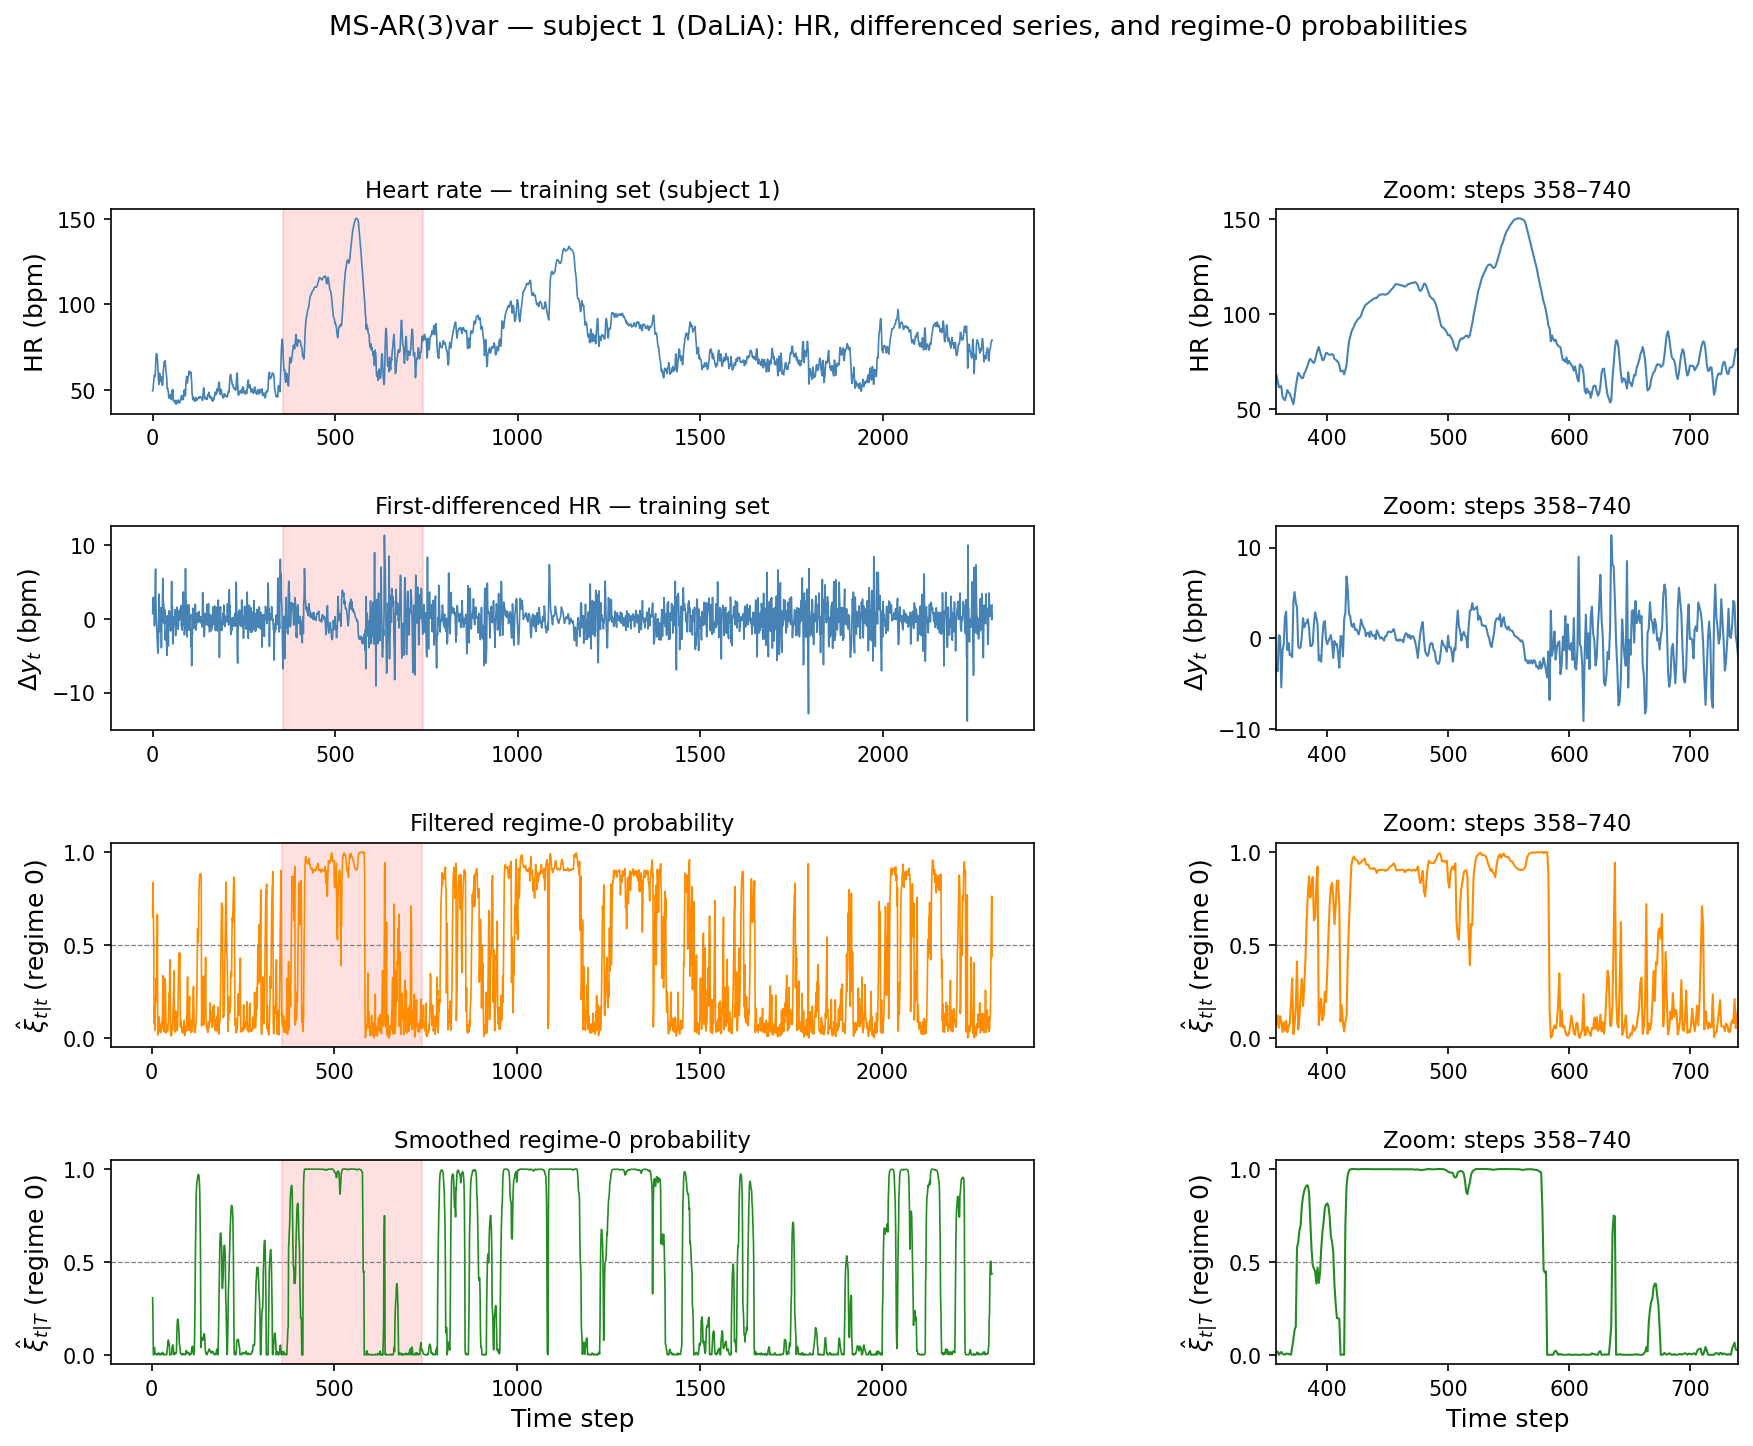

In [74]:
import matplotlib
matplotlib.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
})
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── parameters ────────────────────────────────────────────────────
subject_id = 0
ZOOM_START = 358
ZOOM_END   = 740

# ── data slices ───────────────────────────────────────────────────
differenced_hrs = [(hrs[i] - hrs[i].shift(1)).iloc[1:].reset_index(drop=True)
                   for i in range(m)]

n = len(differenced_hrs[subject_id])
end_obs_idx = n * 50 // 100

hr_train   = hrs[subject_id].iloc[:end_obs_idx]
diff_train = differenced_hrs[subject_id][:end_obs_idx]

filtered0 = results_msar3var[subject_id].filtered_marginal_probabilities.iloc[:, 0]
smoothed0 = results_msar3var[subject_id].smoothed_marginal_probabilities.iloc[:, 0]

# ── figure layout: 4 rows × 2 cols (full | zoom) ──────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(4, 2, width_ratios=[2, 1], hspace=0.55, wspace=0.35)

labels = [
    'HR (bpm)',
    r'$\Delta y_t$ (bpm)',
    r'$\hat{\xi}_{t|t}$ (regime 0)',
    r'$\hat{\xi}_{t|T}$ (regime 0)',
]
titles_full = [
    'Heart rate — training set (subject 1)',
    'First-differenced HR — training set',
    'Filtered regime-0 probability',
    'Smoothed regime-0 probability',
]

series = [
    (hr_train.index,   hr_train.values),
    (diff_train.index, diff_train.values),
    (filtered0.index,  filtered0.values),
    (smoothed0.index,  smoothed0.values),
]

colors = ['steelblue', 'steelblue', 'darkorange', 'forestgreen']

axes_left  = []
axes_right = []

for row in range(4):
    ax_l = fig.add_subplot(gs[row, 0])
    ax_r = fig.add_subplot(gs[row, 1])
    axes_left.append(ax_l)
    axes_right.append(ax_r)

    x, y = series[row]
    x = np.array(x)
    y = np.array(y)

    # full series
    ax_l.plot(x, y, color=colors[row], linewidth=0.8)
    ax_l.set_ylabel(labels[row])
    ax_l.set_title(titles_full[row], fontsize=11)
    ax_l.axvspan(ZOOM_START, ZOOM_END, alpha=0.12, color='red')

    # zoom
    mask = (x >= ZOOM_START) & (x <= ZOOM_END)
    ax_r.plot(x[mask], y[mask], color=colors[row], linewidth=1.0)
    ax_r.set_xlim(ZOOM_START, ZOOM_END)
    ax_r.set_ylabel(labels[row])
    ax_r.set_title(f'Zoom: steps {ZOOM_START}–{ZOOM_END}', fontsize=11)

    # fix y-axis range for probability panels
    if row >= 2:
        ax_l.set_ylim(-0.05, 1.05)
        ax_r.set_ylim(-0.05, 1.05)
        ax_l.axhline(0.5, color='grey', linewidth=0.6, linestyle='--')
        ax_r.axhline(0.5, color='grey', linewidth=0.6, linestyle='--')

    # x-label only on bottom row
    if row == 3:
        ax_l.set_xlabel('Time step')
        ax_r.set_xlabel('Time step')

fig.suptitle(
    'MS-AR(3)var — subject 1 (DaLiA): HR, differenced series, and regime-0 probabilities',
    fontsize=13, y=1.01
)

plt.savefig('msar3var_training_regimes_subject1.pdf', bbox_inches='tight')
plt.savefig('msar3var_training_regimes_subject1.png', bbox_inches='tight', dpi=150)
print("Saved msar3var_training_regimes_subject1.pdf and .png")
plt.show()

In [75]:
# We can also clearly see that here in the test set, until 3500 approx we are in state 1
# because it is mainly just noise
# then in the increasing phase, especially we see it from 3821 to 3841 we switch to state 0

fig = make_subplots(rows = 4, cols = 1)

subject_id = 0

n = len(differenced_hrs[subject_id])
end_obs_idx = n*50//100

partial_differenced_hrs = [differenced_hrs[i].iloc[end_obs_idx:] for i in range(m)]

fig.add_trace(
go.Scatter(x=hrs[subject_id].iloc[end_obs_idx:].index, y=hrs[subject_id].iloc[end_obs_idx:].values, mode="lines"),
row=1, col=1
)
fig.add_trace(
go.Scatter(x=partial_differenced_hrs[subject_id].index, y=partial_differenced_hrs[subject_id].values, mode="lines"),
row=2, col=1
)
fig.add_trace(
go.Scatter(x=probas_state0_forecast_msar3var[subject_id].index, y=probas_state0_forecast_msar3var[subject_id].values, mode="lines"),
row=3, col=1
)
fig.add_trace(
go.Scatter(x=probas_state0_filtered_msar3var[subject_id].index, y=probas_state0_filtered_msar3var[subject_id].values, mode="lines"),
row=4, col=1
)

fig.show()

# Wild PPG

In [76]:
def load_domain_data(domain_idx):
    """Loads wrist PPG and heart rate data for a single subject (domain).

    Args:
        domain_idx (int): Index of the subject (0–15).

    Returns:
        X (np.ndarray): PPG signal data (n_samples × signal_dim).
        y (np.ndarray): Heart rate values (bpm), adjusted to start from 0.
        d (np.ndarray): Domain labels (same shape as y), equal to domain_idx.
    """
    data_path = 'WildPPG.mat'
    data_all = scipy.io.loadmat(data_path)

    # Load PPG signal and heart rate values
    data = data_all['data_ppg_wrist']
    data_labels = data_all['data_bpm_values']

    domain_idx = int(domain_idx)
    X = data[domain_idx, 0]
    #y = np.squeeze(data_labels[domain_idx][0]).astype(int)
    y = data_labels[domain_idx][0]

    # Mask out invalid samples (e.g., NaNs, infs, and HR < 30 bpm)
    mask_Y = y >= 30
    y = y[mask_Y]

    return y

In [77]:
hrs = []

for i in range(16):
    subject = load_domain_data(i)
    hrs.append(pd.Series(subject).reset_index(drop=True))

In [78]:
m = len(hrs)

fig = make_subplots(rows = m, cols = 1, shared_xaxes=True)

for i in range(m):
    fig.add_trace(
        go.Scatter(y=hrs[i]),
        row=i+1, col=1
    )

fig.show()

In [79]:
trains_ar3, tests_ar3, models_ar3, results_ar3 = model_training_arima(hrs, 3, False, 0, 50)

In [80]:
print(results_ar3[0].summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2997
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -8489.191
Date:                Wed, 25 Mar 2026   AIC                          16986.382
Time:                        18:12:24   BIC                          17010.404
Sample:                             0   HQIC                         16995.023
                               - 2997                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7358      0.013     57.091      0.000       0.711       0.761
ar.L2          0.1041      0.018      5.839      0.000       0.069       0.139
ar.L3          0.1591      0.013     11.975      0.0

In [81]:
predictions_ar3 = forecast_arima(results_ar3, tests_ar3)

100%|██████████| 2757/2757 [00:11<00:00, 241.85it/s]


In [82]:
maes_our_partial_ar3, rmses_our_partial_ar3 = compute_errors(series = tests_ar3, forecast = predictions_ar3)

In [83]:
# Naive prediction on test set

naive_maes_partial, naive_rmses_partial = errors_naive(hrs, 50)

In [84]:
# We see that ar(3) is better than naive

for i in range(m):
    print(f"---Subject {i}---")
    print("Our MAE: ", maes_our_partial_ar3[i], "Naive MAE: ", naive_maes_partial[i])
    print("Our RMSE: ", rmses_our_partial_ar3[i], "Naive RMSE: ", naive_rmses_partial[i])

---Subject 0---
Our MAE:  2.984313784107177 Naive MAE:  3.183639613584968
Our RMSE:  4.012038507587105 Naive RMSE:  4.235297797599305
---Subject 1---
Our MAE:  2.9138062232723803 Naive MAE:  3.044736226018201
Our RMSE:  3.9141822191379765 Naive RMSE:  4.103263049218676
---Subject 2---
Our MAE:  3.3889665136352596 Naive MAE:  3.516450467537521
Our RMSE:  4.617504411730043 Naive RMSE:  4.787899935115908
---Subject 3---
Our MAE:  2.961939221005076 Naive MAE:  3.1275380039739233
Our RMSE:  3.9377094997230206 Naive RMSE:  4.164838200068616
---Subject 4---
Our MAE:  4.231363218817248 Naive MAE:  4.437098366611976
Our RMSE:  7.061472933669327 Naive RMSE:  7.485268948247706
---Subject 5---
Our MAE:  7.03504697937011 Naive MAE:  7.791166971712725
Our RMSE:  13.303555069957127 Naive RMSE:  15.402213671419265
---Subject 6---
Our MAE:  2.9072134990635807 Naive MAE:  3.1075132699905765
Our RMSE:  3.90902132318305 Naive RMSE:  4.219598489087629
---Subject 7---
Our MAE:  3.1483016545616493 Naive MAE:

In [85]:
# collect all results in a pandas DataFrame

index = [f"subject{i}" for i in range(1, 17)]

df = pd.DataFrame(
    {
        "AR(3) maes_partial": maes_our_partial_ar3,
        "AR(3) rmses_partial": rmses_our_partial_ar3,
        "Naive maes_partial": naive_maes_partial,
        "Naive rmses_partial": naive_rmses_partial,
    },
    index=index
)

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial
subject1,2.984314,4.012039,3.183640,4.235298
subject2,2.913806,3.914182,3.044736,4.103263
subject3,3.388967,4.617504,3.516450,4.787900
subject4,2.961939,3.937709,3.127538,4.164838
subject5,4.231363,7.061473,4.437098,7.485269
subject6,7.035047,13.303555,7.791167,15.402214
subject7,2.907213,3.909021,3.107513,4.219598
subject8,3.148302,4.204586,3.299420,4.381400
subject9,5.434270,12.370525,5.269269,13.063894
subject10,5.081657,7.933994,5.314354,8.579458


In [86]:
# Now we will first do ARIMA instead of AR which hopefully will give better results already
# No intercept here (adding one almost doesnt change anything)

trains_arima3, tests_arima3, models_arima3, results_arima3 = model_training_arima(hrs, 3, False, 1, 50)

In [87]:
print(results_arima3[0].summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2997
Model:               SARIMAX(3, 1, 0)   Log Likelihood               -8483.953
Date:                Wed, 25 Mar 2026   AIC                          16975.906
Time:                        18:15:35   BIC                          16999.926
Sample:                             0   HQIC                         16984.547
                               - 2997                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2637      0.013    -20.450      0.000      -0.289      -0.238
ar.L2         -0.1593      0.013    -11.908      0.000      -0.186      -0.133
ar.L3          0.0005      0.015      0.035      0.9

In [88]:
# Freeze training parameters and predict 1 step ahead based on true previous values, forecast ARIMA(1,1,0)

predictions_arima3 = forecast_arima(results_arima3, tests_arima3)

  0%|          | 0/2997 [00:00<?, ?it/s]

100%|██████████| 2757/2757 [00:11<00:00, 245.07it/s]


In [89]:
#ARIMA(1,1,0) errors

maes_our_partial_arima, rmses_our_partial_arima = compute_errors(series = tests_arima3, forecast = predictions_arima3)

In [90]:
# ARIMA(3,1,0) does slightly better than AR(3) but still does not outperform their AR(3)

df["ARIMA(3,1,0) maes_partial"] = maes_our_partial_arima
df["ARIMA(3,1,0) rmses_partial"] = rmses_our_partial_arima

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial"
subject1,2.984314,4.012039,3.183640,4.235298,2.981560,4.012722
subject2,2.913806,3.914182,3.044736,4.103263,2.906548,3.910171
subject3,3.388967,4.617504,3.516450,4.787900,3.356331,4.580634
subject4,2.961939,3.937709,3.127538,4.164838,2.940839,3.924105
subject5,4.231363,7.061473,4.437098,7.485269,4.226479,7.040834
subject6,7.035047,13.303555,7.791167,15.402214,7.014913,13.058830
subject7,2.907213,3.909021,3.107513,4.219598,2.901030,3.908466
subject8,3.148302,4.204586,3.299420,4.381400,3.139317,4.200658
subject9,5.434270,12.370525,5.269269,13.063894,5.181767,12.262540
subject10,5.081657,7.933994,5.314354,8.579458,4.979997,7.824839


In [91]:
maes_xgboost, rmses_xgboost = predict_xgboost(hrs, 50)

In [92]:
df["XGBoost maes_partial"] = maes_xgboost
df["XGBoost rmses_partial"] = rmses_xgboost

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial
subject1,2.984314,4.012039,3.183640,4.235298,2.981560,4.012722,2.911123,3.911049
subject2,2.913806,3.914182,3.044736,4.103263,2.906548,3.910171,2.918018,3.947208
subject3,3.388967,4.617504,3.516450,4.787900,3.356331,4.580634,3.341153,4.572022
subject4,2.961939,3.937709,3.127538,4.164838,2.940839,3.924105,2.920156,3.876882
subject5,4.231363,7.061473,4.437098,7.485269,4.226479,7.040834,4.308181,6.909116
subject6,7.035047,13.303555,7.791167,15.402214,7.014913,13.058830,7.117086,13.095339
subject7,2.907213,3.909021,3.107513,4.219598,2.901030,3.908466,2.904429,3.932557
subject8,3.148302,4.204586,3.299420,4.381400,3.139317,4.200658,3.173410,4.296542
subject9,5.434270,12.370525,5.269269,13.063894,5.181767,12.262540,5.928289,12.694392
subject10,5.081657,7.933994,5.314354,8.579458,4.979997,7.824839,5.289059,8.021742


In [93]:
# We are now going to implement a markov switching model and hope it beats their AR(3)
# Train Test 50-50 split and model training MS_AR(3) on differenced series

trains_msar3var, tests_msar3var, models_msar3var, results_msar3var = model_training_msar(
        data = hrs,
        order = 3,
        switching_var = True,
        train_percent = 50
)

c:\Users\Alex Achotian\Desktop\non stationary\datasets\DaLiA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [94]:
parameters_msar3var = model_parameters(results_msar3var)

In [95]:
differenced_forecasts_msar3var, probas_state0_forecast_msar3var, probas_state0_filtered_msar3var = forecast_msar(
    parameters_msar3var,
    results_msar3var,
    trains_msar3var,
    tests_msar3var
)

In [96]:
maes_msar3var, rmses_msar3var = compute_errors(series = tests_msar3var, forecast = differenced_forecasts_msar3var)

In [97]:
df["MSAR(3)var diff maes_partial"] = maes_msar3var
df["MSAR(3)var diff rmses_partial"] = rmses_msar3var

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial
subject1,2.984314,4.012039,3.183640,4.235298,2.981560,4.012722,2.911123,3.911049,2.945456,3.964515
subject2,2.913806,3.914182,3.044736,4.103263,2.906548,3.910171,2.918018,3.947208,2.931124,3.989087
subject3,3.388967,4.617504,3.516450,4.787900,3.356331,4.580634,3.341153,4.572022,3.371839,4.604663
subject4,2.961939,3.937709,3.127538,4.164838,2.940839,3.924105,2.920156,3.876882,2.925061,3.907744
subject5,4.231363,7.061473,4.437098,7.485269,4.226479,7.040834,4.308181,6.909116,4.215501,7.033661
subject6,7.035047,13.303555,7.791167,15.402214,7.014913,13.058830,7.117086,13.095339,6.969077,13.059622
subject7,2.907213,3.909021,3.107513,4.219598,2.901030,3.908466,2.904429,3.932557,2.890958,3.900998
subject8,3.148302,4.204586,3.299420,4.381400,3.139317,4.200658,3.173410,4.296542,3.122725,4.183627
subject9,5.434270,12.370525,5.269269,13.063894,5.181767,12.262540,5.928289,12.694392,5.196594,12.354992
subject10,5.081657,7.933994,5.314354,8.579458,4.979997,7.824839,5.289059,8.021742,4.973380,7.815242


In [98]:
# We are now going to implement a markov switching model and hope it beats their AR(3)
# Train Test 50-50 split and model training MS_AR(3) on differenced series

trains_msar3, tests_msar3, models_msar3, results_msar3 = model_training_msar(
        data = hrs,
        order = 3,
        switching_var = False,
        train_percent = 50
)

In [99]:
parameters_msar3 = model_parameters(results_msar3)

In [100]:
differenced_forecasts_msar3, probas_state0_forecast_msar3, probas_state0_filtered_msar3 = forecast_msar(
    parameters_msar3,
    results_msar3,
    trains_msar3,
    tests_msar3
)

In [101]:
maes_msar3, rmses_msar3 = compute_errors(series = tests_msar3, forecast = differenced_forecasts_msar3)

In [102]:
df["MSAR(3) diff maes_partial"] = maes_msar3
df["MSAR(3) diff rmses_partial"] = rmses_msar3

df

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial,MSAR(3) diff maes_partial,MSAR(3) diff rmses_partial
subject1,2.984314,4.012039,3.183640,4.235298,2.981560,4.012722,2.911123,3.911049,2.945456,3.964515,2.933277,3.948900
subject2,2.913806,3.914182,3.044736,4.103263,2.906548,3.910171,2.918018,3.947208,2.931124,3.989087,2.897420,3.907792
subject3,3.388967,4.617504,3.516450,4.787900,3.356331,4.580634,3.341153,4.572022,3.371839,4.604663,3.355801,4.579529
subject4,2.961939,3.937709,3.127538,4.164838,2.940839,3.924105,2.920156,3.876882,2.925061,3.907744,2.930577,3.932083
subject5,4.231363,7.061473,4.437098,7.485269,4.226479,7.040834,4.308181,6.909116,4.215501,7.033661,4.224708,7.047502
subject6,7.035047,13.303555,7.791167,15.402214,7.014913,13.058830,7.117086,13.095339,6.969077,13.059622,7.053303,13.397128
subject7,2.907213,3.909021,3.107513,4.219598,2.901030,3.908466,2.904429,3.932557,2.890958,3.900998,2.866604,3.886233
subject8,3.148302,4.204586,3.299420,4.381400,3.139317,4.200658,3.173410,4.296542,3.122725,4.183627,3.114730,4.212054
subject9,5.434270,12.370525,5.269269,13.063894,5.181767,12.262540,5.928289,12.694392,5.196594,12.354992,5.169312,12.282959
subject10,5.081657,7.933994,5.314354,8.579458,4.979997,7.824839,5.289059,8.021742,4.973380,7.815242,4.953530,7.847442


In [103]:
# we see that the best forecast is from:
# - msar(3) var 8/15
# - msar(3) 6/15
# - arima(3,1,0) 1/15
# - ar(3) 0/15
# - naive 0/15
df.style.highlight_min(axis=1, props="font-weight:bold;")

,AR(3) maes_partial,AR(3) rmses_partial,Naive maes_partial,Naive rmses_partial,"ARIMA(3,1,0) maes_partial","ARIMA(3,1,0) rmses_partial",XGBoost maes_partial,XGBoost rmses_partial,MSAR(3)var diff maes_partial,MSAR(3)var diff rmses_partial,MSAR(3) diff maes_partial,MSAR(3) diff rmses_partial
subject1,2.984314,4.012039,3.183640,4.235298,2.981560,4.012722,2.911123,3.911049,2.945456,3.964515,2.933277,3.948900
subject2,2.913806,3.914182,3.044736,4.103263,2.906548,3.910171,2.918018,3.947208,2.931124,3.989087,2.897420,3.907792
subject3,3.388967,4.617504,3.516450,4.787900,3.356331,4.580634,3.341153,4.572022,3.371839,4.604663,3.355801,4.579529
subject4,2.961939,3.937709,3.127538,4.164838,2.940839,3.924105,2.920156,3.876882,2.925061,3.907744,2.930577,3.932083
subject5,4.231363,7.061473,4.437098,7.485269,4.226479,7.040834,4.308181,6.909116,4.215501,7.033661,4.224708,7.047502
subject6,7.035047,13.303555,7.791167,15.402214,7.014913,13.058830,7.117086,13.095339,6.969077,13.059622,7.053303,13.397128
subject7,2.907213,3.909021,3.107513,4.219598,2.901030,3.908466,2.904429,3.932557,2.890958,3.900998,2.866604,3.886233
subject8,3.148302,4.204586,3.299420,4.381400,3.139317,4.200658,3.173410,4.296542,3.122725,4.183627,3.114730,4.212054
subject9,5.434270,12.370525,5.269269,13.063894,5.181767,12.262540,5.928289,12.694392,5.196594,12.354992,5.169312,12.282959
subject10,5.081657,7.933994,5.314354,8.579458,4.979997,7.824839,5.289059,8.021742,4.973380,7.815242,4.953530,7.847442


In [104]:
print(results_msar3var[0].summary())

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                 2993
Model:             MarkovAutoregression   Log Likelihood               -8221.260
Date:                  Wed, 25 Mar 2026   AIC                          16462.519
Time:                          18:21:44   BIC                          16522.560
Sample:                               0   HQIC                         16484.118
                                 - 2993                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        41.9182      3.236     12.955      0.000      35.577      48.260
ar.L1         -0.1025      0.054    

In [105]:
fig = make_subplots(rows = 4, cols = 1)

subject_id = 0

differenced_hrs = [(hrs[i]-hrs[i].shift(1)).iloc[1:].reset_index(drop=True) for i in range(m)]
n = len(differenced_hrs[subject_id])

filtered0 = results_msar3var[subject_id].filtered_marginal_probabilities.iloc[:,0]
smoothed0 = results_msar3var[subject_id].smoothed_marginal_probabilities.iloc[:,0]

end_obs_idx = n*50//100

fig.add_trace(
go.Scatter(x=hrs[subject_id].iloc[:end_obs_idx].index, y=hrs[subject_id].iloc[:end_obs_idx].values, mode="lines"),
row=1, col=1
)
fig.add_trace(
go.Scatter(x=differenced_hrs[subject_id][:end_obs_idx].index, y=differenced_hrs[subject_id][:end_obs_idx].values, mode="lines"),
row=2, col=1
)
fig.add_trace(
go.Scatter(x=filtered0.index, y=filtered0.values, mode="lines"),
row=3, col=1
)
fig.add_trace(
go.Scatter(x=smoothed0.index, y=smoothed0.values, mode="lines"),
row=4, col=1
)

fig.show()

In [106]:
fig = make_subplots(rows = 4, cols = 1)

subject_id = 0

n = len(differenced_hrs[subject_id])
end_obs_idx = n*50//100

partial_differenced_hrs = [differenced_hrs[i].iloc[end_obs_idx:] for i in range(m)]

fig.add_trace(
go.Scatter(x=hrs[subject_id].iloc[end_obs_idx:].index, y=hrs[subject_id].iloc[end_obs_idx:].values, mode="lines"),
row=1, col=1
)
fig.add_trace(
go.Scatter(x=partial_differenced_hrs[subject_id].index, y=partial_differenced_hrs[subject_id].values, mode="lines"),
row=2, col=1
)
fig.add_trace(
go.Scatter(x=probas_state0_forecast_msar3var[subject_id].index, y=probas_state0_forecast_msar3var[subject_id].values, mode="lines"),
row=3, col=1
)
fig.add_trace(
go.Scatter(x=probas_state0_filtered_msar3var[subject_id].index, y=probas_state0_filtered_msar3var[subject_id].values, mode="lines"),
row=4, col=1
)

fig.show()

In [107]:
## ACF AND PACF PLOTS 

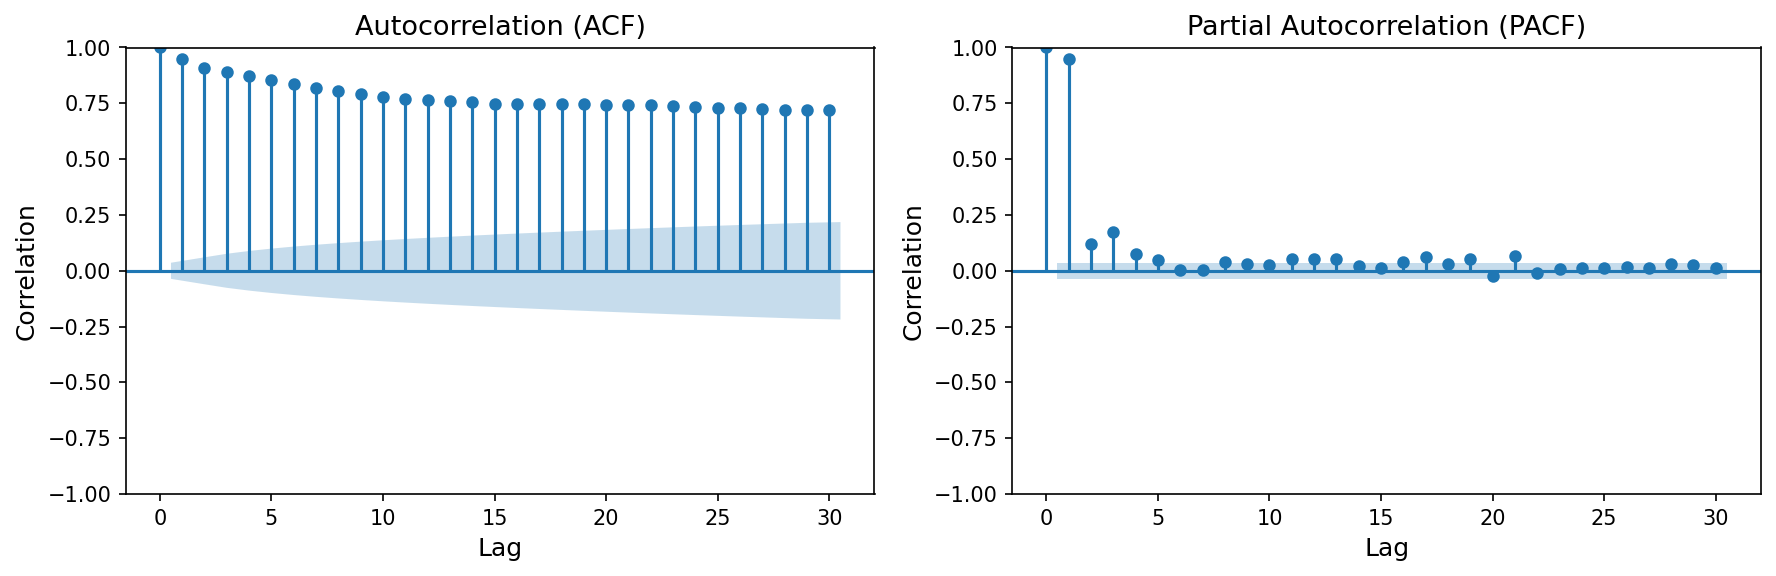

In [108]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = hrs[2].iloc[:len(hrs[2])//2] 

# number of lags to display
max_lags = 30

# create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(series, lags=max_lags, ax=axes[0], title="Autocorrelation (ACF)")
plot_pacf(series, lags=max_lags, ax=axes[1], title="Partial Autocorrelation (PACF)")

for ax in axes:
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")

plt.tight_layout()
plt.savefig("acf_pacf_dalia_levels.pdf", bbox_inches="tight")


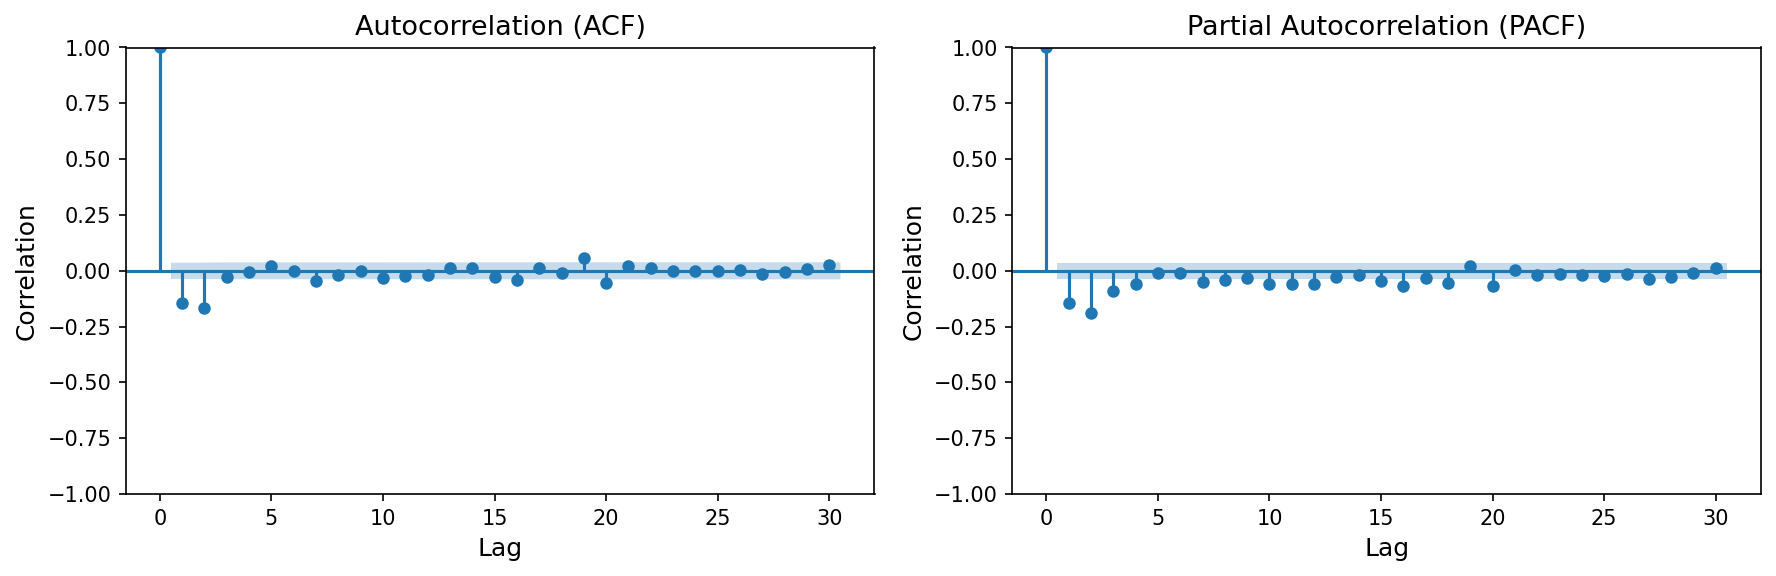

In [109]:
m = len(hrs)
differenced_hrs = [(hrs[i]-hrs[i].shift(1)).iloc[1:].reset_index(drop=True) for i in range(m)]

series = differenced_hrs[2].iloc[:len(differenced_hrs[2])//2]   

# number of lags to display
max_lags = 30

# create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(series, lags=max_lags, ax=axes[0], title="Autocorrelation (ACF)")
plot_pacf(series, lags=max_lags, ax=axes[1], title="Partial Autocorrelation (PACF)")

for ax in axes:
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")

plt.tight_layout()
plt.savefig("acf_pacf_dalia_differenced_levels.pdf", bbox_inches="tight")
